# World trade trends, 1995-2024

This notebook studies world trade relative to world GDP and identifies the main turning points over the latest 30 complete years.

## Measure and interpretation

The main measure is **merchandise trade as a percentage of GDP**:

`Trade openness (%) = (exports + imports) / world GDP * 100`

This is the closest match to UN Comtrade or BACI because those databases describe trade in goods. The notebook also plots the broader World Bank measure that includes goods and services. Both numerator and denominator are in current US dollars, so the ratio is internally consistent.

Important: this is a value-based openness measure, not a real trade-volume index. Commodity prices and exchange rates can therefore move the series even when physical trade volumes change less.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
import zipfile
from pathlib import Path
from urllib.error import HTTPError
from urllib.parse import urlencode
from urllib.request import urlopen

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path(r'C:\Users\Popov\Documents\Studies\IMT_studies\Python\International_trade')
BENCHMARK_CSV = DATA_DIR / 'world_trade_trends.csv'
OUTPUT_PNG = DATA_DIR / 'world_trade_openness.png'
BACI_CLEAN_CSV = DATA_DIR / 'baci_world_trade_annual_clean.csv'
COMTRADE_CLEAN_CSV = DATA_DIR / 'un_comtrade_selected_years_check.csv'

## Data

The supplied CSV contains the World Bank world aggregates for 1995-2024:

- `TG.VAL.TOTL.GD.ZS`: merchandise trade (% of GDP), used as the main series and as a compact benchmark for a Comtrade/BACI reconstruction.
- `NE.TRD.GNFS.ZS`: trade in goods and services (% of GDP), shown for comparison.

The last complete year is 2024. The 2025 world aggregate is not used because it is still incomplete/preliminary.

## Exact data sources

The values **actually used in the CSV and plotted in this notebook** were downloaded from the World Bank API for the `WLD` (World) aggregate and the years 1995-2024.

| CSV column / use | World Bank indicator | Exact data link |
|---|---|---|
| `merchandise_trade_pct_gdp` (main line) | `TG.VAL.TOTL.GD.ZS` - Merchandise trade (% of GDP) | https://api.worldbank.org/v2/country/WLD/indicator/TG.VAL.TOTL.GD.ZS?format=json&per_page=100&date=1995:2024 |
| `trade_goods_services_pct_gdp` (comparison line) | `NE.TRD.GNFS.ZS` - Trade in goods and services (% of GDP) | https://api.worldbank.org/v2/country/WLD/indicator/NE.TRD.GNFS.ZS?format=json&per_page=100&date=1995:2024 |
| World GDP used only by the optional BACI reconstruction cell | `NY.GDP.MKTP.CD` - GDP (current US$) | https://api.worldbank.org/v2/country/WLD/indicator/NY.GDP.MKTP.CD?format=json&per_page=100&date=1995:2024 |

The two plotted series are stored locally in `world_trade_trends.csv`. They were retrieved on 17 September 2026. **No BACI observations were downloaded or used in the current chart.** BACI appears only as an optional reconstruction method; its official description and download page is https://www.cepii.fr/DATA_DOWNLOAD/baci/doc/baci_webpage.html.


In [2]:
data = pd.read_csv(BENCHMARK_CSV)
data['merchandise_yoy_pp'] = data['merchandise_trade_pct_gdp'].diff()
data['goods_services_yoy_pp'] = data['trade_goods_services_pct_gdp'].diff()
data.tail()

,year,merchandise_trade_pct_gdp,trade_goods_services_pct_gdp,merchandise_yoy_pp,goods_services_yoy_pp
25,2020,41.19,51.87,-2.05,-3.93
26,2021,45.54,56.50,4.35,4.63
27,2022,49.32,62.15,3.78,5.65
28,2023,45.03,58.07,-4.29,-4.08
29,2024,44.30,56.72,-0.73,-1.35


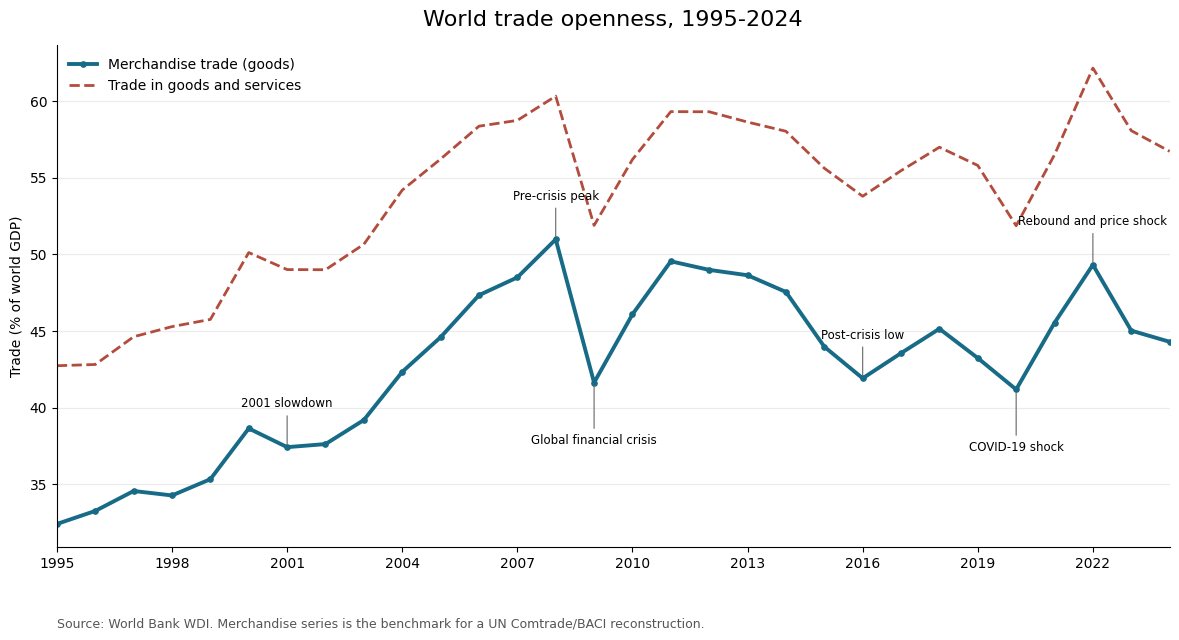

In [3]:
fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(
    data['year'], data['merchandise_trade_pct_gdp'],
    color='#176B87', linewidth=2.8, marker='o', markersize=3.8,
    label='Merchandise trade (goods)'
)
ax.plot(
    data['year'], data['trade_goods_services_pct_gdp'],
    color='#B24C3D', linewidth=2.0, linestyle='--',
    label='Trade in goods and services'
)

events = {
    2001: '2001 slowdown',
    2008: 'Pre-crisis peak',
    2009: 'Global financial crisis',
    2016: 'Post-crisis low',
    2020: 'COVID-19 shock',
    2022: 'Rebound and price shock',
}

for year, label in events.items():
    value = data.loc[data['year'].eq(year), 'merchandise_trade_pct_gdp'].iloc[0]
    offset = 2.6 if year not in (2009, 2020) else -4.0
    ax.annotate(
        label, xy=(year, value), xytext=(year, value + offset),
        ha='center', fontsize=8.5,
        arrowprops={'arrowstyle': '-', 'color': '#666666', 'lw': 0.8}
    )

ax.set_title('World trade openness, 1995-2024', fontsize=16, pad=14)
ax.set_ylabel('Trade (% of world GDP)')
ax.set_xlabel('')
ax.set_xlim(1995, 2024)
ax.set_xticks(range(1995, 2025, 3))
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper left')
ax.text(
    0, -0.16,
    'Source: World Bank WDI. Merchandise series is the benchmark for a UN Comtrade/BACI reconstruction.',
    transform=ax.transAxes, fontsize=9, color='#555555'
)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches='tight')
plt.show()

## Objective check: largest annual changes

The following table avoids choosing turning points only by eye. It ranks the largest one-year increases and decreases in merchandise trade as a share of GDP.

In [4]:
largest_falls = (
    data.nsmallest(5, 'merchandise_yoy_pp')
        [['year', 'merchandise_trade_pct_gdp', 'merchandise_yoy_pp']]
        .assign(direction='fall')
)
largest_rises = (
    data.nlargest(5, 'merchandise_yoy_pp')
        [['year', 'merchandise_trade_pct_gdp', 'merchandise_yoy_pp']]
        .assign(direction='rise')
)

largest_moves = pd.concat([largest_falls, largest_rises], ignore_index=True)
largest_moves.sort_values('merchandise_yoy_pp')

,year,merchandise_trade_pct_gdp,merchandise_yoy_pp,direction
0,2009,41.64,-9.34,fall
1,2023,45.03,-4.29,fall
2,2015,43.98,-3.57,fall
3,2016,41.92,-2.06,fall
4,2020,41.19,-2.05,fall
9,2000,38.65,3.31,rise
8,2011,49.55,3.46,rise
7,2022,49.32,3.78,rise
6,2021,45.54,4.35,rise
5,2010,46.09,4.45,rise


## Main turning points

1. **1995-2000: expansion.** Merchandise trade rose from 32.42% to 38.65% of world GDP. This was the late-1990s phase of globalization and expanding global value chains.
2. **2001: short interruption.** The ratio fell to 37.43% during the global slowdown. China's WTO membership began in December 2001; the event is relevant to the subsequent expansion, but the graph alone does not prove causality.
3. **2002-2008: strongest sustained rise.** The ratio reached a 30-year high of 50.98% in 2008, supported by rapid global growth, China's integration, global value chains, and rising commodity prices.
4. **2009: largest collapse.** The ratio dropped by 9.34 percentage points to 41.64% during the global financial crisis.
5. **2010-2011: rapid rebound.** Merchandise trade recovered to 49.55%, close to its pre-crisis peak.
6. **2012-2016: prolonged slowdown.** The ratio declined to 41.92%. This is consistent with slower global growth, weaker commodity prices, policy uncertainty, and maturing global value chains.
7. **2017-2018: partial recovery; 2019-2020: renewed fall.** Trade reached 45.15% in 2018, then weakened in 2019 and fell to 41.19% during the pandemic in 2020.
8. **2021-2022: powerful rebound.** The ratio rose to 49.32% in 2022. Part of this was real recovery, but high energy and commodity prices also raised nominal trade values.
9. **2023-2024: normalization.** Merchandise trade fell to 45.03% and then 44.30% of GDP as commodity prices eased and goods demand weakened. It remained above the 2020 low but below the 2008 and 2022 peaks.

**Conclusion.** The last 30 years are not a story of continuous deglobalization. They show a large pre-2008 globalization wave, a post-crisis plateau/slowdown, and sharp shock-rebound cycles in 2009 and 2020-2022.

## Cross-checks with BACI and UN Comtrade

The next cells independently reconstruct merchandise trade relative to GDP from BACI and check selected turning-point years against raw UN Comtrade totals. The World Bank series remains the main plotted benchmark. Differences are expected because the sources use different estimation, reconciliation, valuation, and coverage procedures.

For BACI, download the **HS92 version 202601** ZIP from CEPII and place the ZIP unchanged anywhere inside `DATA_DIR`. The code searches recursively and also supports extracted annual files. BACI contains one reconciled FOB flow per exporter-importer-product-year, so summing `v` gives world exports; multiplying by two approximates the conventional global `exports + imports` numerator. BACI values are in thousands of current US dollars.

In [5]:
WORLD_GDP_URL = (
    'https://api.worldbank.org/v2/country/WLD/indicator/'
    'NY.GDP.MKTP.CD?format=json&per_page=100&date=1995:2024'
)

def fetch_json(url, attempts=5, pause=2.2):
    for attempt in range(attempts):
        try:
            with urlopen(url) as response:
                return json.load(response)
        except HTTPError as error:
            if error.code != 429 or attempt == attempts - 1:
                raise
            time.sleep(pause * (attempt + 1))

def fetch_world_gdp():
    payload = fetch_json(WORLD_GDP_URL)
    return pd.DataFrame(
        {'year': int(row['date']), 'world_gdp_usd': row['value']}
        for row in payload[1] if row['value'] is not None
    ).sort_values('year')

In [6]:
def sum_baci_file(file_or_buffer):
    year = None
    total_thousand_usd = 0.0
    for chunk in pd.read_csv(
        file_or_buffer, usecols=['t', 'v'], chunksize=500_000
    ):
        if year is None:
            year = int(chunk['t'].iloc[0])
        total_thousand_usd += chunk['v'].sum()
    return year, total_thousand_usd * 1_000

baci_csv_files = sorted(DATA_DIR.rglob('BACI_HS92_Y*_V*.csv'))
baci_zip_files = sorted(DATA_DIR.rglob('BACI_HS92_V*.zip'))
baci = pd.DataFrame()
baci_source = None
created_clean_baci = False

if BACI_CLEAN_CSV.exists():
    baci = pd.read_csv(BACI_CLEAN_CSV)
    baci_source = str(BACI_CLEAN_CSV)
else:
    annual_exports = []
    source_version = None
    if baci_csv_files:
        baci_source = f'{len(baci_csv_files)} extracted annual CSV files'
        source_version = baci_csv_files[-1].stem.rsplit('_V', 1)[-1]
        for file in baci_csv_files:
            print(f'Processing {file.name} ...')
            year, exports_usd = sum_baci_file(file)
            annual_exports.append({
                'year': year, 'baci_world_exports_usd': exports_usd
            })
    elif baci_zip_files:
        baci_archive = baci_zip_files[-1]
        baci_source = str(baci_archive)
        source_version = baci_archive.stem.rsplit('_V', 1)[-1]
        with zipfile.ZipFile(baci_archive) as archive:
            members = sorted(
                name for name in archive.namelist()
                if Path(name).name.startswith('BACI_HS92_Y')
                and Path(name).name.endswith('.csv')
            )
            for member in members:
                print(f'Processing {Path(member).name} ...')
                with archive.open(member) as file:
                    year, exports_usd = sum_baci_file(file)
                annual_exports.append({
                    'year': year, 'baci_world_exports_usd': exports_usd
                })

    if annual_exports:
        baci = pd.DataFrame(annual_exports).drop_duplicates('year')
        baci = baci.merge(fetch_world_gdp(), on='year', how='inner')
        baci['baci_merchandise_trade_pct_gdp'] = (
            2 * baci['baci_world_exports_usd']
            / baci['world_gdp_usd'] * 100
        )
        baci['baci_source_version'] = source_version
        baci = baci.sort_values('year')
        baci.to_csv(BACI_CLEAN_CSV, index=False)
        created_clean_baci = True

if baci.empty:
    baci_check = pd.DataFrame()
    print('BACI check not run: no cleaned file, annual CSVs, or HS92 ZIP found.')
    print(f'Place BACI_HS92_V202601.zip inside: {DATA_DIR}')
else:
    baci_check = data[[
        'year', 'merchandise_trade_pct_gdp'
    ]].merge(
        baci[['year', 'baci_merchandise_trade_pct_gdp']],
        on='year', how='inner'
    )
    baci_check['baci_minus_world_bank_pp'] = (
        baci_check['baci_merchandise_trade_pct_gdp']
        - baci_check['merchandise_trade_pct_gdp']
    )
    print(f'BACI source: {baci_source}')
    if created_clean_baci:
        print(f'Created reusable cleaned dataset: {BACI_CLEAN_CSV}')
        print('After verifying this CSV, the large BACI ZIP is no longer needed.')
    display(baci_check.sort_values('year'))

BACI source: C:\Users\Popov\Documents\Studies\IMT_studies\Python\International_trade\baci_world_trade_annual_clean.csv


,year,merchandise_trade_pct_gdp,baci_merchandise_trade_pct_gdp,baci_minus_world_bank_pp
0,1995,32.42,32.37,-0.05
1,1996,33.27,33.48,0.21
2,1997,34.57,35.05,0.48
3,1998,34.28,34.96,0.68
4,1999,35.34,35.08,-0.26
5,2000,38.65,38.38,-0.27
6,2001,37.43,37.49,0.06
7,2002,37.63,37.84,0.21
8,2003,39.20,39.02,-0.18
9,2004,42.34,41.79,-0.55


### UN Comtrade check

This check downloads total merchandise imports and exports for every available non-group reporter from the official UN Comtrade public API. It checks selected turning-point years rather than downloading the full product-level database. The `reporter_count` column makes incomplete coverage visible, especially for the latest year. Imports are normally CIF while exports are FOB, so this raw calculation need not equal either BACI or the World Bank indicator exactly.

In [7]:
COMTRADE_REPORTERS_URL = (
    'https://comtradeapi.un.org/files/v1/app/reference/Reporters.json'
)
COMTRADE_DATA_API = (
    'https://comtradeapi.un.org/public/v1/preview/C/A/HS'
)
COMTRADE_CHECK_YEARS = [1995, 2000, 2008, 2009, 2011, 2016, 2020, 2022, 2024]

if COMTRADE_CLEAN_CSV.exists():
    comtrade = pd.read_csv(COMTRADE_CLEAN_CSV)
    print(f'Using cached UN Comtrade check: {COMTRADE_CLEAN_CSV}')
else:
    reporter_payload = fetch_json(COMTRADE_REPORTERS_URL)
    reporters = pd.DataFrame(reporter_payload['results'])
    reporter_codes = sorted(
        reporters.loc[
            ~reporters['isGroup'], 'reporterCode'
        ].astype(int).unique()
    )
    reporter_codes_text = ','.join(map(str, reporter_codes))

    comtrade_rows = []
    for year in COMTRADE_CHECK_YEARS:
        params = {
            'period': year,
            'reporterCode': reporter_codes_text,
            'cmdCode': 'TOTAL',
            'flowCode': 'X,M',
            'partnerCode': 0,
            'partner2Code': 0,
            'customsCode': 'C00',
            'motCode': 0,
            'maxRecords': 500,
        }
        url = COMTRADE_DATA_API + '?' + urlencode(params, safe=',')
        payload = fetch_json(url)
        annual = pd.DataFrame(payload['data'])
        annual['primaryValue'] = pd.to_numeric(annual['primaryValue'])
        comtrade_rows.append({
            'year': year,
            'comtrade_exports_usd': annual.loc[
                annual['flowCode'].eq('X'), 'primaryValue'
            ].sum(),
            'comtrade_imports_usd': annual.loc[
                annual['flowCode'].eq('M'), 'primaryValue'
            ].sum(),
            'reporter_count': annual['reporterCode'].nunique(),
            'record_count': len(annual),
        })
        time.sleep(2.2)  # Respect the public API rate limit.

    comtrade = pd.DataFrame(comtrade_rows).merge(
        fetch_world_gdp(), on='year', how='left'
    )
    comtrade['comtrade_merchandise_trade_pct_gdp'] = (
        (
            comtrade['comtrade_exports_usd']
            + comtrade['comtrade_imports_usd']
        ) / comtrade['world_gdp_usd'] * 100
    )
    comtrade.to_csv(COMTRADE_CLEAN_CSV, index=False)
    print(f'Saved UN Comtrade check: {COMTRADE_CLEAN_CSV}')

comtrade_check = data[[
    'year', 'merchandise_trade_pct_gdp'
]].merge(
    comtrade[[
        'year', 'comtrade_merchandise_trade_pct_gdp',
        'reporter_count', 'record_count'
    ]],
    on='year', how='inner'
)
comtrade_check['comtrade_minus_world_bank_pp'] = (
    comtrade_check['comtrade_merchandise_trade_pct_gdp']
    - comtrade_check['merchandise_trade_pct_gdp']
)
display(comtrade_check)

Using cached UN Comtrade check: C:\Users\Popov\Documents\Studies\IMT_studies\Python\International_trade\un_comtrade_selected_years_check.csv


,year,merchandise_trade_pct_gdp,comtrade_merchandise_trade_pct_gdp,reporter_count,record_count,comtrade_minus_world_bank_pp
0,1995,32.42,30.06,116,229,-2.36
1,2000,38.65,36.68,166,329,-1.97
2,2008,50.98,48.82,176,347,-2.16
3,2009,41.64,39.86,176,347,-1.78
4,2011,49.55,47.45,175,345,-2.10
5,2016,41.92,40.33,177,353,-1.59
6,2020,41.19,39.26,168,336,-1.93
7,2022,49.32,46.16,166,332,-3.16
8,2024,44.30,39.26,139,278,-5.04


### Cross-check findings

All three sources identify the same major turning points: expansion to 2008, the 2009 collapse, recovery in 2010-2011, the mid-2010s slowdown, the 2020 shock, and the 2021-2022 rebound. For BACI 202601, the mean absolute difference from the World Bank merchandise ratio is 1.10 percentage points; the largest difference is 3.41 points in provisional 2024 data. For the selected UN Comtrade years, the mean absolute difference is 2.45 points and the largest is 5.04 points in 2024. The raw UN result is lower partly because only 139 reporters were available for 2024, compared with as many as 177 in earlier check years, while BACI and the World Bank apply different reconciliation and estimation procedures.

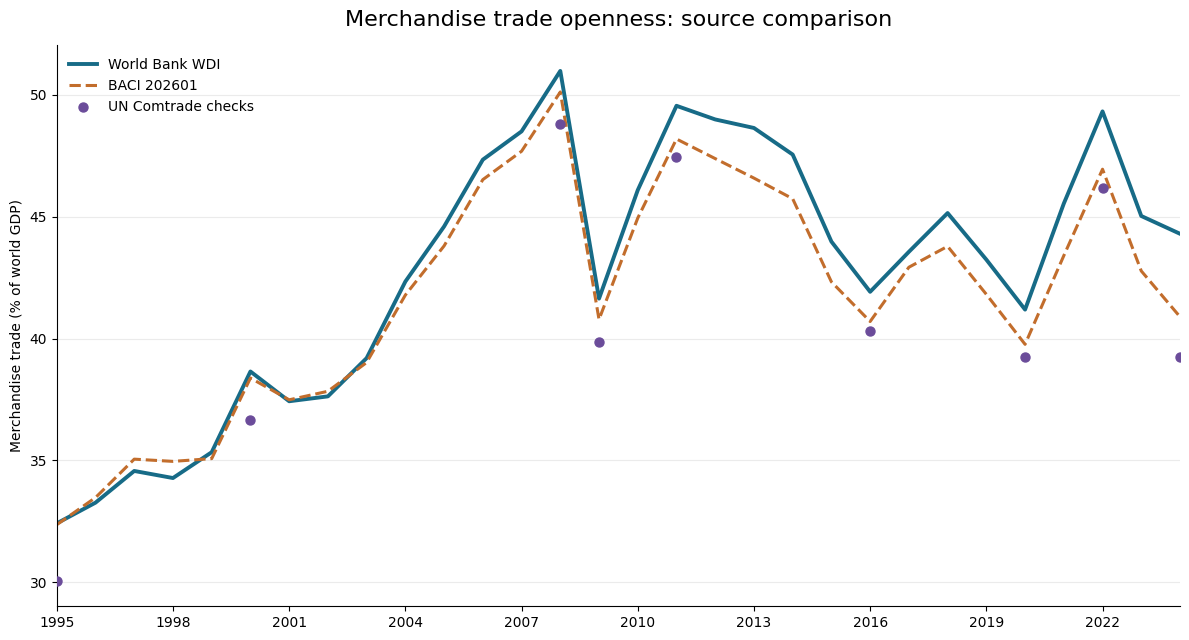

In [8]:
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(
    data['year'], data['merchandise_trade_pct_gdp'],
    color='#176B87', linewidth=2.8, label='World Bank WDI'
)
if not baci_check.empty:
    ax.plot(
        baci_check['year'], baci_check['baci_merchandise_trade_pct_gdp'],
        color='#C26D2C', linewidth=2.2, linestyle='--', label='BACI 202601'
    )
ax.scatter(
    comtrade_check['year'],
    comtrade_check['comtrade_merchandise_trade_pct_gdp'],
    color='#6B4C9A', s=42, zorder=3, label='UN Comtrade checks'
)
ax.set_title('Merchandise trade openness: source comparison', fontsize=16, pad=14)
ax.set_ylabel('Merchandise trade (% of world GDP)')
ax.set_xlabel('')
ax.set_xlim(1995, 2024)
ax.set_xticks(range(1995, 2025, 3))
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig(DATA_DIR / 'trade_source_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Sources

- World Bank WDI, merchandise trade (% of GDP): https://data.worldbank.org/indicator/TG.VAL.TOTL.GD.ZS
- World Bank WDI, trade in goods and services (% of GDP): https://data.worldbank.org/indicator/NE.TRD.GNFS.ZS
- CEPII BACI description and downloads: https://www.cepii.fr/DATA_DOWNLOAD/baci/doc/baci_webpage.html
- UN Comtrade: https://comtradeplus.un.org/
- UN Comtrade reporter codes: https://comtradeapi.un.org/files/v1/app/reference/Reporters.json
- UN Comtrade public API endpoint used for checks: https://comtradeapi.un.org/public/v1/preview/C/A/HS
- WTO merchandise trade statistics: https://www.wto.org/english/res_e/statis_e/merch_trade_stat_e.htm